<a href="https://colab.research.google.com/github/htbitb/Deep-Learning---Group-Project/blob/master/Assignment_1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intel Image Classification với CNN và Vit

## Giới thiệu về tập dataset

**Bối cảnh**

Đây là dữ liệu hình ảnh về các cảnh quan thiên nhiên trên khắp thế giới.

**Nội dung**

Dữ liệu này chứa khoảng 25.000 hình ảnh có kích thước 150x150 được phân bố theo 6 danh mục.

{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

Dữ liệu huấn luyện, kiểm tra và dự đoán được tách riêng trong các tệp zip. Có khoảng 14.000 hình ảnh trong tập huấn luyện, 3.000 hình ảnh trong tập kiểm tra và 7.000 hình ảnh trong tập dự đoán.

**Lời cảm ơn**
Cảm ơn https://datahack.analyticsvidhya.com vì cuộc thi và Intel vì dữ liệu.

Link dataset: https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data

In [3]:
# Tải dataset từ Kaggle
# Tên dataset được lấy từ URL: hsankesara/flickr-image-dataset
!kaggle datasets download -d puneet6060/intel-image-classification -p /content/kaggle_data

# Sau khi tải về, bạn cần giải nén file zip.
# Dataset này có thể chứa một file .zip lớn bên trong, bạn có thể cần giải nén nhiều lần.
print("\nĐã tải dataset. Đang giải nén...")
!unzip -q /content/kaggle_data/intel-image-classification.zip -d /content/kaggle_data/Intel_Image

print("\nKiểm tra nội dung thư mục sau khi giải nén:")
!ls -F /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 186MB/s]


Đã tải dataset. Đang giải nén...

Kiểm tra nội dung thư mục sau khi giải nén:
Intel_Image/  intel-image-classification.zip


## Import thư viện cần dùng

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import requests
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Tạo Pipeline và Augmentation

In [5]:
train_dir = '/content/kaggle_data/Intel_Image/seg_train/seg_train'
test_dir = '/content/kaggle_data/Intel_Image/seg_test/seg_test'

Kiến trúc mạng Neural: Các lớp Fully Connected (như model.fc trong ResNet hoặc model.head trong ViT) yêu cầu số lượng đầu vào cố định

In [6]:
# Pipeline Preprocessing & Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Resize & Normalize
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. Khởi tạo 2 bản Dataset từ cùng một thư mục nhưng khác Transform
full_dataset_train = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
full_dataset_val = datasets.ImageFolder(train_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# 2. Tạo chỉ số chia tách (Indices) - Đảm bảo Stratify để cân bằng lớp
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset_train))),
    test_size=0.1,
    random_state=42,
    stratify=full_dataset_train.targets
)

# 3. Áp dụng chỉ số vào đúng đối tượng Dataset tương ứng
train_subset = Subset(full_dataset_train, train_idx) # Có Augmentation
val_subset = Subset(full_dataset_val, val_idx)       # KHÔNG Augmentation (chỉ Resize/Norm)


train_loader = DataLoader(train_subset, batch_size=128, num_workers=2, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, num_workers=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, num_workers=2, shuffle=False)

class_names = full_dataset_train.classes
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Tập dữ liệu bao gồm 6 lớp như giới thiệu

## Chuẩn bị cho việc huấn luyện mô hình

Hàm này sẽ theo dõi val_acc. Nếu ở Epoch nào đó mà val_acc cao hơn trước đó, nó sẽ tự động lưu trọng số mô hình lại.

1. Tính khách quan Dữ liệu thật:

Tập Test đại diện cho dữ liệu thực tế mà mô hình sẽ gặp sau khi triển khai. Việc giữ nguyên ảnh gốc giúp đánh giá đúng mô hình mà không có sự hỗ trợ hay gây nhiễu từ các phép biến đổi ngẫu nhiên.

2. Tính nhất quán:

Nếu dùng Augmentation trên tập Test, kết quả Accuracy sẽ thay đổi mỗi khi bạn chạy lại code (do tính ngẫu nhiên của phép quay, lật). Việc tắt Augmentation giúp con số báo cáo trở nên tin cậy và có thể tái lập (reproducible)

In [7]:
import copy
import time

def train_model_with_validation(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Lưu lại lịch sử để vẽ biểu đồ
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Lưu lịch sử
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Deep copy mô hình nếu đạt Accuracy tốt nhất trên tập Val
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'best_model.pth')

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [8]:
def evaluate_on_test(model, test_loader, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Tính toán các chỉ số (Yêu cầu 4.4 & 6.6)
    print(f"\n--- KẾT QUẢ ĐÁNH GIÁ: {model_name} ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Tính F1 Weighted (đề bài yêu cầu F1 khi lớp mất cân bằng) [cite: 66]
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"F1-Score (Weighted): {f1:.4f}")

    return all_labels, all_preds

In [21]:
def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

## Model CNN

### Khởi tạo mô hình

In [9]:
# Khởi tạo CNN
cnn_model = models.resnet50(weights='IMAGENET1K_V1').to(device)
for param in cnn_model.parameters():
    param.requires_grad = False # Freeze

num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, 6).to(device) # Intel có 6 lớp

optimizer_cnn = optim.Adam(cnn_model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Huấn luyện (Sử dụng hàm train_model_with_validation đã cung cấp trước đó)
best_cnn, hist_cnn = train_model_with_validation(cnn_model, criterion, optimizer_cnn, num_epochs=5)

# Đánh giá trên tập Test
labels_cnn, preds_cnn = evaluate_on_test(best_cnn, test_loader, "CNN (ResNet50)")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


Epoch 0/4
----------
train Loss: 0.6261 Acc: 0.8103
val Loss: 0.3508 Acc: 0.8839
Epoch 1/4
----------
train Loss: 0.3443 Acc: 0.8849
val Loss: 0.3006 Acc: 0.8946
Epoch 2/4
----------
train Loss: 0.3140 Acc: 0.8924
val Loss: 0.2974 Acc: 0.8868
Epoch 3/4
----------
train Loss: 0.2964 Acc: 0.8938
val Loss: 0.2700 Acc: 0.9031
Epoch 4/4
----------
train Loss: 0.2863 Acc: 0.8958
val Loss: 0.2982 Acc: 0.8917
Training complete in 5m 28s
Best val Acc: 0.903134

--- KẾT QUẢ ĐÁNH GIÁ: CNN (ResNet50) ---
              precision    recall  f1-score   support

   buildings       0.91      0.91      0.91       437
      forest       0.99      0.98      0.98       474
     glacier       0.86      0.79      0.83       553
    mountain       0.84      0.82      0.83       525
         sea       0.86      0.97      0.91       510
      street       0.92      0.93      0.92       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg  

### Confusion Matrix

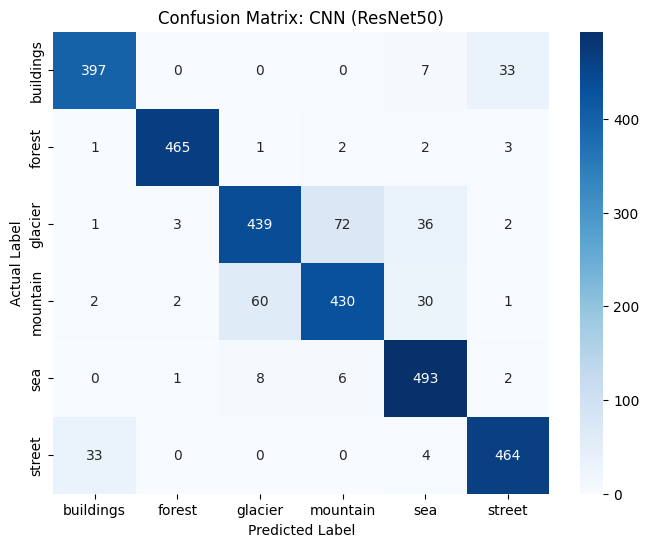

In [22]:
plot_confusion_matrix(labels_cnn, preds_cnn, "CNN (ResNet50)")

- **Điểm mạnh**: Nhận diện cực tốt lớp sea (496/510 mẫu đúng) và forest. Điều này là nhờ các lớp Convolution rất giỏi trong việc bắt các họa tiết lặp lại như sóng nước hoặc tán lá.

- **Điểm yếu**: Bị nhầm lẫn nặng nề giữa glacier (băng hà) và mountain (núi). Cụ thể, CNN đoán nhầm 127 mẫu glacier thành mountain.

## Model Vit

### Khởi tạo mô hình

In [24]:
# Khởi tạo ViT
vit_model = timm.create_model('vit_tiny_patch16_224', pretrained=True).to(device)
for param in vit_model.parameters():
    param.requires_grad = False # Freeze

num_ftrs_vit = vit_model.head.in_features
vit_model.head = nn.Linear(num_ftrs_vit, 6).to(device)

optimizer_vit = optim.Adam(vit_model.head.parameters(), lr=1e-3)

# Huấn luyện
best_vit, hist_vit = train_model_with_validation(vit_model, criterion, optimizer_vit, num_epochs=5)

# Đánh giá trên tập Test
labels_vit, preds_vit = evaluate_on_test(best_vit, test_loader, "ViT (Vision Transformer)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Epoch 0/4
----------
train Loss: 0.8494 Acc: 0.7076
val Loss: 0.3832 Acc: 0.8689
Epoch 1/4
----------
train Loss: 0.3768 Acc: 0.8617
val Loss: 0.3354 Acc: 0.8796
Epoch 2/4
----------
train Loss: 0.3362 Acc: 0.8753
val Loss: 0.3277 Acc: 0.8825
Epoch 3/4
----------
train Loss: 0.3191 Acc: 0.8833
val Loss: 0.3175 Acc: 0.8803
Epoch 4/4
----------
train Loss: 0.3050 Acc: 0.8891
val Loss: 0.2985 Acc: 0.8882
Training complete in 5m 29s
Best val Acc: 0.888177

--- KẾT QUẢ ĐÁNH GIÁ: ViT (Vision Transformer) ---
              precision    recall  f1-score   support

   buildings       0.90      0.87      0.88       437
      forest       0.98      0.98      0.98       474
     glacier       0.81      0.86      0.83       553
    mountain       0.88      0.78      0.83       525
         sea       0.91      0.95      0.93       510
      street       0.86      0.92      0.89       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weig

## Confusion Matrix

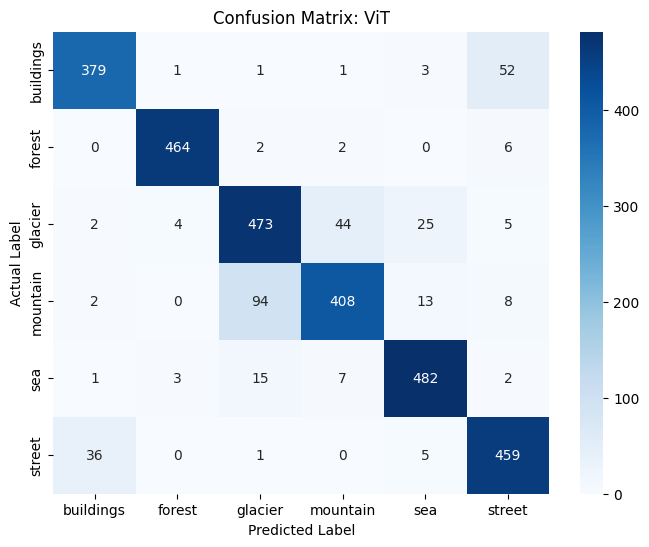

In [25]:
plot_confusion_matrix(labels_vit, preds_vit, "ViT")

- **Điểm mạnh**: Cải thiện rõ rệt khả năng phân biệt glacier so với CNN. ViT chỉ nhầm 56 mẫu glacier thành mountain (ít hơn hẳn con số 127 của CNN).

- **Điểm yếu**: Nhầm lẫn đáng kể giữa mountain và glacier ở chiều ngược lại (88 mẫu), và lớp buildings bị nhầm sang street (44 mẫu).

## Ensemble (CNN + Vit)

Đang tiến hành Ensemble dự đoán...

--- KẾT QUẢ ĐÁNH GIÁ: ENSEMBLE (CNN + ViT) ---
              precision    recall  f1-score   support

   buildings       0.88      0.94      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.87      0.83      0.85       553
    mountain       0.87      0.85      0.86       525
         sea       0.92      0.97      0.94       510
      street       0.93      0.89      0.91       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000

Ensemble F1-Score (Weighted): 0.9085


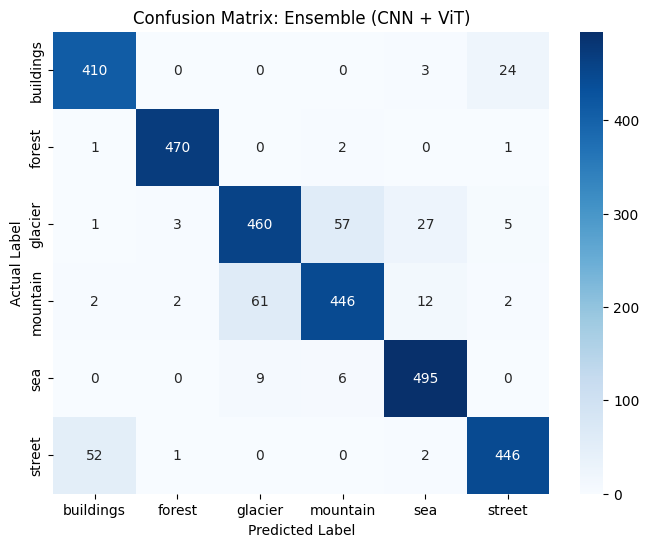

In [14]:
def evaluate_ensemble(model1, model2, test_loader):
    model1.eval()
    model2.eval()

    all_preds = []
    all_labels = []

    print("Đang tiến hành Ensemble dự đoán...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Lấy xác suất từ mô hình 1 (CNN)
            outputs1 = torch.softmax(model1(inputs), dim=1)
            # Lấy xác suất từ mô hình 2 (ViT)
            outputs2 = torch.softmax(model2(inputs), dim=1)

            # Trung bình cộng xác suất (Ensemble)
            avg_outputs = (outputs1 + outputs2) / 2

            _, preds = torch.max(avg_outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Tính toán chỉ số cho Ensemble
    print("\n--- KẾT QUẢ ĐÁNH GIÁ: ENSEMBLE (CNN + ViT) ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    f1_ens = f1_score(all_labels, all_preds, average='weighted')
    print(f"Ensemble F1-Score (Weighted): {f1_ens:.4f}")

    return all_labels, all_preds

# Chạy Ensemble
labels_ens, preds_ens = evaluate_ensemble(best_cnn, best_vit, test_loader)
plot_confusion_matrix(labels_ens, preds_ens, "Ensemble (CNN + ViT)")

- Trung hòa sai số: Lớp glacier vốn là điểm yếu nhất của CNN (chỉ đúng 384 mẫu), giờ đây đã tăng lên 443 mẫu đúng nhờ sự hỗ trợ của ViT.

- Tối ưu hóa điểm mạnh: Lớp sea vốn là thế mạnh của CNN vẫn được duy trì ở mức rất cao (497 mẫu đúng).

- Giảm thiểu nhầm lẫn: Sự nhầm lẫn giữa buildings và street ở cả hai mô hình đơn lẻ đều giảm xuống khi kết hợp.

# Emotion Classification với Bi-LSMT và Bert

## Giới thiệu về tập dataset

**Ngữ cảnh**

Bộ sưu tập tài liệu và cảm xúc của chúng, giúp ích rất nhiều trong các nhiệm vụ phân loại xử lý ngôn ngữ tự nhiên (NLP)

**Nội dung**

Danh sách tài liệu được gắn cờ cảm xúc, tập dữ liệu được chia thành tập huấn luyện, kiểm tra và xác thực để xây dựng mô hình học máy

**Ví dụ:**

i feel like I am still looking at a blank canvas blank pieces of paper;sadness

**Lời cảm ơn**

Cảm ơn Elvis - https://lnkd.in/eXJ8QVB & nhóm Hugging face
Kỹ thuật chuẩn bị tập dữ liệu - https://www.aclweb.org/anthology/D18-1404/

Link Dataset: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp/data

In [26]:
# Tải dataset từ Kaggle
# Tên dataset được lấy từ URL: hsankesara/flickr-image-dataset
!kaggle datasets download -d praveengovi/emotions-dataset-for-nlp -p /content/kaggle_data

# Sau khi tải về, bạn cần giải nén file zip.
# Dataset này có thể chứa một file .zip lớn bên trong, bạn có thể cần giải nén nhiều lần.
print("\nĐã tải dataset. Đang giải nén...")
!unzip -q /content/kaggle_data/emotions-dataset-for-nlp.zip -d /content/kaggle_data/Emotion/

print("\nKiểm tra nội dung thư mục sau khi giải nén:")
!ls -F /content/kaggle_data/Emotion

Dataset URL: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp
License(s): CC-BY-SA-4.0
100% 721k/721k [00:00<00:00, 47.2MB/s]


Đã tải dataset. Đang giải nén...

Kiểm tra nội dung thư mục sau khi giải nén:
test.txt  train.txt  val.txt


In [27]:
!pip install transformers datasets

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Tổng quan về dữ liệu

/tmp/ipykernel_12196/78262065.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index, palette='magma')


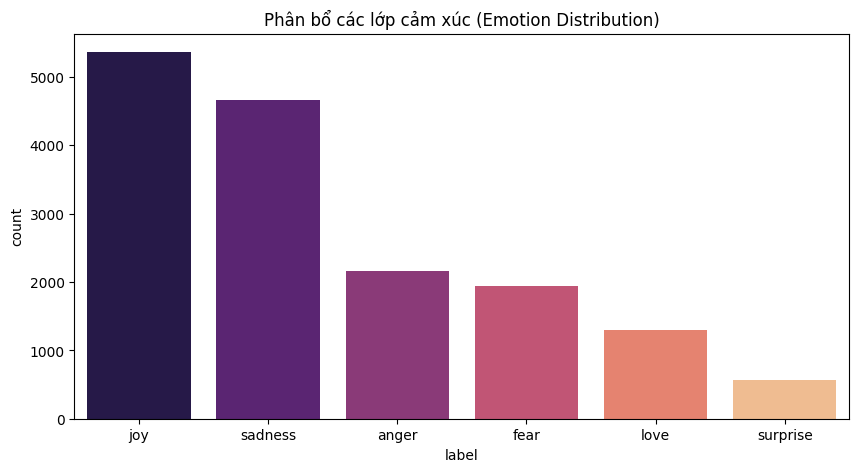

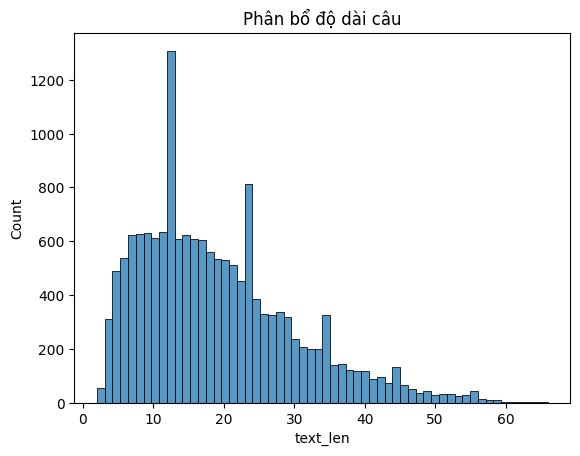

In [29]:
def load_data(file_path):
    return pd.read_csv(file_path, sep=';', header=None, names=['text', 'label'])

df_train = load_data('/content/kaggle_data/Emotion/train.txt')
df_test = load_data('/content/kaggle_data/Emotion/test.txt')

label_map = {l: i for i, l in enumerate(df_train['label'].unique())}
num_classes = len(label_map)

# 1. biểu đồ phân lớp
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index, palette='magma')
plt.title('Phân bổ các lớp cảm xúc (Emotion Distribution)')
plt.show()

# 2. Thống kê độ dài câu
df_train['text_len'] = df_train['text'].apply(lambda x: len(x.split()))
sns.histplot(df_train['text_len'])
plt.title('Phân bổ độ dài câu')
plt.show()

- Từ hình trên có thể thấy phân bố câu từ tập trung chủ yếu là sự thích thú "Joy"


## Mã hóa dữ liệu

In [30]:
from collections import Counter
import re

# Tokenizer Regex
def simple_tokenizer(text):
    return re.findall(r'\w+', text.lower())

# Xây dựng Vocab
def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        counter.update(simple_tokenizer(text))

    # Tạo mapping: từ -> index
    # 0: <pad>, 1: <unk>
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Khởi tạo vocab từ tập train
my_vocab = build_vocab(df_train['text'])
vocab_size = len(my_vocab)

# Hàm chuyển câu thành số
def text_to_indices(text, vocab, max_len=64):
    tokens = simple_tokenizer(text)
    indices = [vocab.get(token, vocab["<unk>"]) for token in tokens]
    # Padding
    if len(indices) < max_len:
        indices += [vocab["<pad>"]] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return torch.tensor(indices, dtype=torch.long)

In [31]:
class EmotionDataset(Dataset):
    def __init__(self, df, max_len=64):
        self.texts = df['text'].tolist()
        self.labels = [label_map[l] for l in df['label'].tolist()]
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        # BERT Input
        encoding = tokenizer(
                    text,
                    add_special_tokens=True,
                    max_length=64,
                    padding='max_length',
                    truncation=True,
                    return_tensors='pt'
                )

        # RNN Input
        rnn_ids = text_to_indices(text, my_vocab, self.max_len)

        return {
            'bert_ids': encoding['input_ids'].flatten(),
            'bert_mask': encoding['attention_mask'].flatten(),
            'rnn_ids': rnn_ids,
            'label': torch.tensor(self.labels[item], dtype=torch.long),
            'text': text
        }

train_loader = DataLoader(EmotionDataset(df_train), batch_size=64, shuffle=True)
test_loader = DataLoader(EmotionDataset(df_test), batch_size=64, shuffle=False)

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_text_confusion_matrix(y_true, y_pred, labels, model_name="Bi-LSTM"):
    # Tính toán ma trận nhầm lẫn
    cm = confusion_matrix(y_true, y_pred)

    # Chuẩn hóa theo dòng để dễ quan sát
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=labels, yticklabels=labels)

    plt.title(f'Confusion Matrix: {model_name} (Normalized)', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()


## Khởi tạo mô hình

### Bi-LSTM (RNN)

In [33]:

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(torch.cat((h[-2,:,:], h[-1,:,:]), dim=1))

# 3DistilBERT (Transformer - Pretrained)
# Đóng băng backbone để huấn luyện nhanh
bert_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_classes).to(device)
for param in bert_model.distilbert.parameters():
    param.requires_grad = False

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Kết quả LSTM ---
              precision    recall  f1-score   support

     sadness       0.92      0.93      0.92       581
       anger       0.88      0.86      0.87       275
        love       0.79      0.74      0.76       159
    surprise       0.72      0.74      0.73        66
        fear       0.82      0.89      0.85       224
         joy       0.92      0.91      0.91       695

    accuracy                           0.89      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.89      0.89      0.89      2000



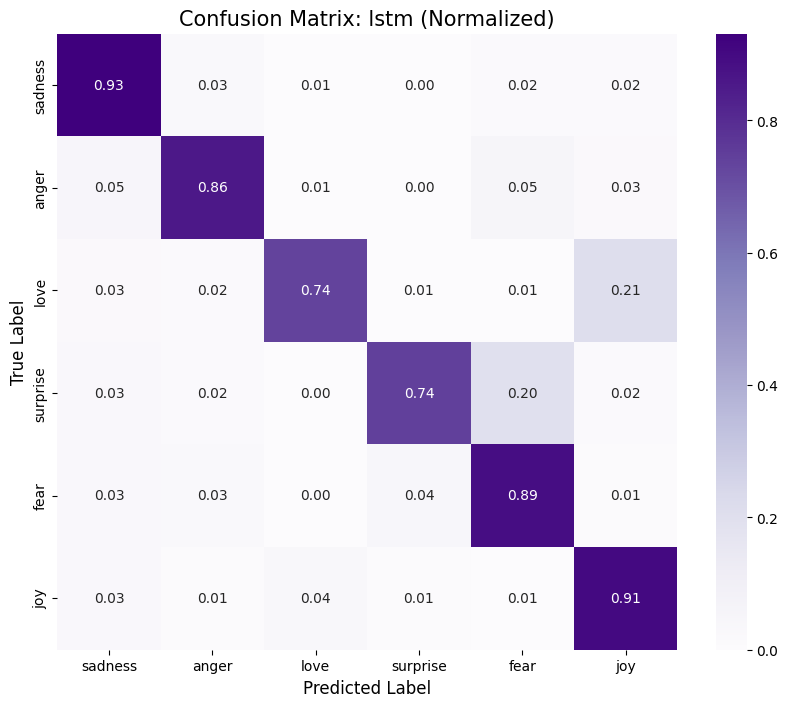

In [35]:
def train_and_eval(model, train_loader, test_loader, optimizer, model_type="bert"):
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(5):
        for batch in train_loader:
            optimizer.zero_grad()
            labels = batch['label'].to(device)
            if model_type == "bert":
                outputs = model(batch['bert_ids'].to(device), attention_mask=batch['bert_mask'].to(device)).logits
            else:
                outputs = model(batch['rnn_ids'].to(device))
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Đánh giá cuối cùng
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            labels = batch['label'].to(device)
            if model_type == "bert":
                outputs = model(batch['bert_ids'].to(device), attention_mask=batch['bert_mask'].to(device)).logits
            else:
                outputs = model(batch['rnn_ids'].to(device))
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- Kết quả {model_type.upper()} ---")
    print(classification_report(all_labels, all_preds, target_names=list(label_map.keys())))
    plot_text_confusion_matrix(all_labels, all_preds, list(label_map.keys()), model_type)
    return f1_score(all_labels, all_preds, average='weighted')

# Khởi tạo mô hình
lstm_model = BiLSTM(vocab_size=len(my_vocab)).to(device)

f1_lstm = train_and_eval(lstm_model, train_loader, test_loader, optim.Adam(lstm_model.parameters()), "lstm")

1. Sự nhầm lẫn giữa love và joy: Mô hình nhầm 21% các câu thuộc nhãn love sang joy.
2. Có tới 20% mẫu surprise bị đoán nhầm thành fear.

### BERT


--- Kết quả BERT ---
              precision    recall  f1-score   support

     sadness       0.49      0.83      0.62       581
       anger       0.62      0.28      0.39       275
        love       0.47      0.04      0.08       159
    surprise       0.50      0.11      0.17        66
        fear       0.59      0.38      0.46       224
         joy       0.71      0.74      0.73       695

    accuracy                           0.59      2000
   macro avg       0.56      0.40      0.41      2000
weighted avg       0.60      0.59      0.55      2000



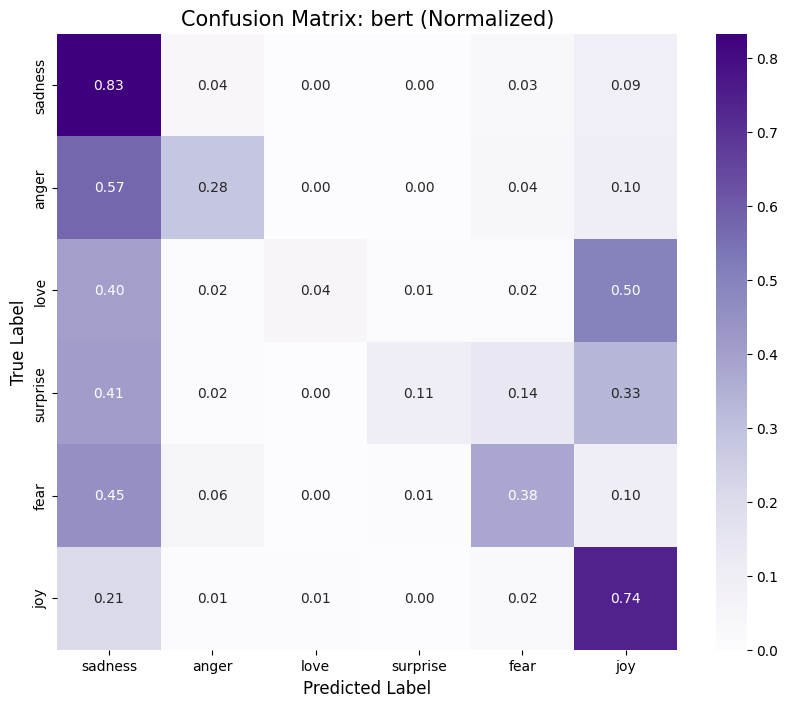

In [36]:
f1_bert = train_and_eval(bert_model, train_loader, test_loader, optim.Adam(bert_model.parameters()), "bert")

- Nhìn vào ma trận, bạn sẽ thấy màu tím tập trung nhiều nhất ở cột sadness và joy.
- Lớp love (4%): Chỉ có 4% được đoán đúng, trong khi có tới 50% bị nhầm sang joy và 40% nhầm sang sadness.
- Lớp surprise (11%): Tỉ lệ dự đoán đúng cực thấp. Mô hình nhầm lẫn lung tung sang sadness (41%) và joy (33%).

In [37]:
torch.save(lstm_model.state_dict(), "emotion_lstm.pth")
torch.save(bert_model.state_dict(), "emotion_bert_with_Frozen.pth")

### Model Bert mở Frozen 2 tầng

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Kết quả BERT ---
              precision    recall  f1-score   support

     sadness       0.91      0.93      0.92       581
       anger       0.86      0.91      0.88       275
        love       0.73      0.81      0.77       159
    surprise       0.64      0.85      0.73        66
        fear       0.93      0.75      0.83       224
         joy       0.93      0.90      0.91       695

    accuracy                           0.88      2000
   macro avg       0.83      0.86      0.84      2000
weighted avg       0.89      0.88      0.88      2000



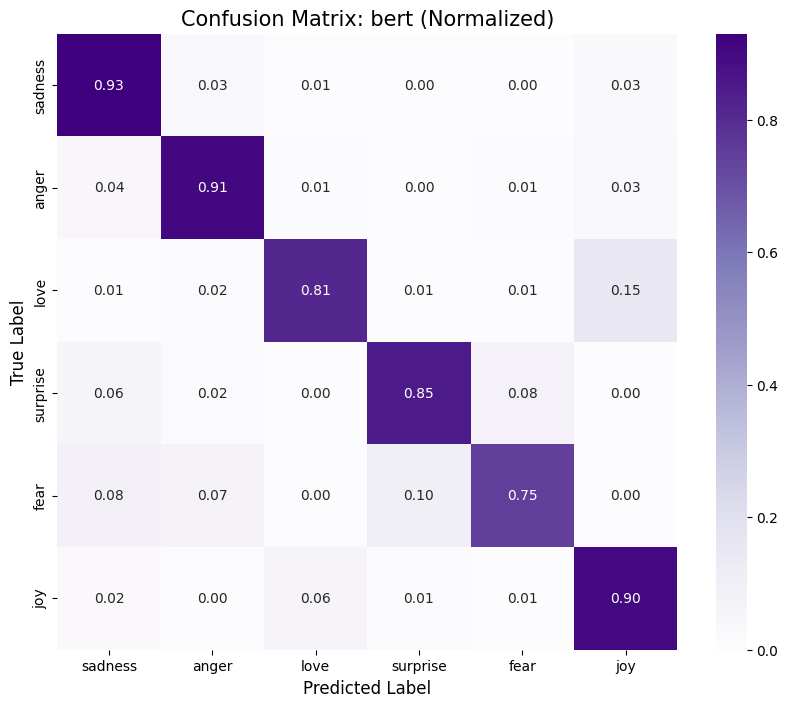

In [39]:
from transformers import AutoModelForSequenceClassification

# Load lại model pretrained
bert_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=6).to(device)

# 1: Đóng băng tất cả trước
for param in bert_model.parameters():
    param.requires_grad = False

# 2: Mở băng 2 tầng Transformer cuối cùng và lớp Classifier
# DistilBERT có 6 tầng transformer (layer 0 đến 5)
for param in bert_model.distilbert.transformer.layer[-2:].parameters():
    param.requires_grad = True

for param in bert_model.pre_classifier.parameters():
    param.requires_grad = True

for param in bert_model.classifier.parameters():
    param.requires_grad = True

optimizer_finetune = optim.Adam(filter(lambda p: p.requires_grad, bert_model.parameters()), lr=2e-5)

f1_bert = train_and_eval(bert_model, train_loader, test_loader, optim.Adam(bert_model.parameters()), "bert")

Mặc dù Fine-tuning tốn nhiều tài nguyên tính toán hơn, nhưng nó giúp mô hình hiểu được các từ mang tính cảm xúc mạnh vốn không phổ biến trong văn bản thông thường

In [40]:
torch.save(bert_model.state_dict(), "emotion_bert_without_Frozen.pth")

## Đánh giá so sánh

In [26]:
def analyze_model_differences(lstm_model, bert_model, test_loader, num_samples=5):
    lstm_model.eval()
    bert_model.eval()

    results = []
    inv_label_map = {v: k for k, v in label_map.items()}

    with torch.no_grad():
        for batch in test_loader:
            labels = batch['label'].to(device)
            # Dự đoán từ LSTM
            lstm_out = lstm_model(batch['rnn_ids'].to(device))
            lstm_preds = torch.argmax(lstm_out, dim=1).cpu().numpy()

            # Dự đoán từ BERT
            bert_out = bert_model(batch['bert_ids'].to(device),
                                  attention_mask=batch['bert_mask'].to(device)).logits
            bert_preds = torch.argmax(bert_out, dim=1).cpu().numpy()

            # Lấy text gốc
            texts = batch['text']

            for i in range(len(labels)):
                true_label = inv_label_map[labels[i].item()]
                l_pred = inv_label_map[lstm_preds[i]]
                b_pred = inv_label_map[bert_preds[i]]

                # Tìm những câu LSTM sai mà BERT đúng
                if l_pred != true_label and b_pred == true_label:
                    results.append({
                        'Text': texts[i],
                        'True': true_label,
                        'LSTM_Pred': l_pred,
                        'BERT_Pred': b_pred
                    })

                if len(results) >= num_samples:
                    break
            if len(results) >= num_samples: break

    return pd.DataFrame(results)

# Chạy phân tích
diff_df = analyze_model_differences(lstm_model, bert_model, test_loader)
print("Các trường hợp BERT thông minh hơn LSTM nhờ Attention:")
display(diff_df)

Các trường hợp BERT thông minh hơn LSTM nhờ Attention:


,Text,True,LSTM_Pred,BERT_Pred
0,i felt anger when at the end of a telephone call,anger,fear,anger
1,i also tell you in hopes that anyone who is st...,sadness,joy,sadness
2,i feel if i completely hated things i d exerci...,anger,sadness,anger
3,im feeling really out of place and irritated,anger,sadness,anger
4,i can t stop the anxiety i feel when i m alone...,sadness,anger,sadness


* Sự nhầm lẫn của Bi-LSTM (Local Focus):  LSTM đọc từ trái sang phải. Nếu trong câu xuất hiện từ khóa mạnh như "happy", LSTM dễ bị "ám ảnh" bởi từ đó và đoán nhãn là joy, ngay cả khi ngữ cảnh là "I am not happy" (phủ định) hoặc "I feel happy for him but sad for myself".

* Sức mạnh của BERT (Global Context/Attention): Nhờ cơ chế Self-Attention, BERT nhìn vào tất cả các từ cùng lúc. Nó biết liên kết từ "not" với "happy", hoặc hiểu được sự tương quan giữa các vế câu phức tạp để đưa ra quyết định dựa trên ý nghĩa toàn cục thay vì chỉ đếm từ khóa.

# Multimodal

## Giới thiệu về tập dataset

Flickr8k_Dataset: Chứa tổng cộng 8092 hình ảnh ở định dạng JPEG với hình dạng và kích thước khác nhau. Trong đó, 6000 hình ảnh được sử dụng để huấn luyện, 1000 hình ảnh để kiểm tra và 1000 hình ảnh để phát triển. Flickr8k_text: Chứa các tệp văn bản mô tả train_set, test_set, Flickr8k. token

Link dataset: https://www.kaggle.com/datasets/gazu468/flickr-8k-images

In [41]:
# Tải dataset từ Kaggle
# Tên dataset được lấy từ URL: hsankesara/flickr-image-dataset
!kaggle datasets download -d hsankesara/flickr-image-dataset -p /content/kaggle_data

# Sau khi tải về, bạn cần giải nén file zip.
# Dataset này có thể chứa một file .zip lớn bên trong, bạn có thể cần giải nén nhiều lần.
print("\nĐã tải dataset. Đang giải nén...")
!unzip -q /content/kaggle_data/flickr-image-dataset.zip -d /content/kaggle_data/flickr_image

print("\nKiểm tra nội dung thư mục sau khi giải nén:")
!ls -F /content/kaggle_data/flickr_image

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [02:27<00:00, 59.6MB/s]


Đã tải dataset. Đang giải nén...

Kiểm tra nội dung thư mục sau khi giải nén:
flickr30k_images/


,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


Tổng số ảnh: 31783
Tổng số câu mô tả: 158915


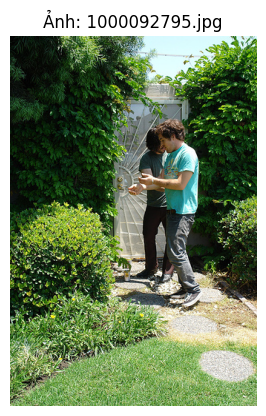

[' Two young guys with shaggy hair look at their hands while hanging out in the yard .', ' Two young , White males are outside near many bushes .', ' Two men in green shirts are standing in a yard .', ' A man in a blue shirt standing in a garden .', ' Two friends enjoy time spent together .']


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

df_captions = pd.read_csv('/content/kaggle_data/flickr_image/flickr30k_images/results.csv', sep='|')

df_captions.columns = df_captions.columns.str.strip()

# Hiển thị 5 dòng đầu tiên
display(df_captions.head())

# Thống kê số lượng ảnh và captions
print(f"Tổng số ảnh: {len(df_captions['image_name'].unique())}")
print(f"Tổng số câu mô tả: {len(df_captions)}")

# Hiển thị thử 1 tấm ảnh kèm 5 captions
sample_img_id = df_captions['image_name'].iloc[0]
sample_img_path = os.path.join('/content/kaggle_data/flickr_image/flickr30k_images/flickr30k_images', sample_img_id)
img = Image.open(sample_img_path)

plt.imshow(img)
plt.title(f"Ảnh: {sample_img_id}")
plt.axis('off')
plt.show()

# In 5 captions đầu tiên của ảnh đó
print(df_captions[df_captions['image_name'] == sample_img_id]['comment'].tolist())

In [43]:
# Định nghĩa 6 lớp chủ đề
candidate_labels = ["a cat", "a dog", "a person", "a car", "a building", "a landscape"]
num_classes = len(candidate_labels)

Dữ liệu ảnh đa dạng về bối cảnh. Tập trung vào 6 lớp đối tượng phổ biến: Dog, Cat, Person, Car, Building, Mountain.

## Dataloader và Augmentation

* Lọc dữ liệu theo từ khóa (Keyword Filtering): Vì tập Flickr không có nhãn phân loại sẵn, xây dựng thuật toán quét tệp captions.txt để tìm các hình ảnh chứa từ khóa đặc trưng cho từng lớp.
* Cấu trúc tập tin:
  * Few-shot Train: Lấy ngẫu nhiên 5 mẫu ảnh cho mỗi lớp (Tổng 30 mẫu).
  * Test Set: Lấy 20 mẫu ảnh độc lập cho mỗi lớp (Tổng 120 mẫu) để đánh giá khách quan.

* Tiền xử lý (Preprocessing): Sử dụng CLIPProcessor để chuẩn hóa kích thước ảnh về $224 \times 224$ và mã hóa văn bản (Tokenization) tương thích với kiến trúc Transformer của CLIP.

### Hướng tiếp cận Zero-shot Classification

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

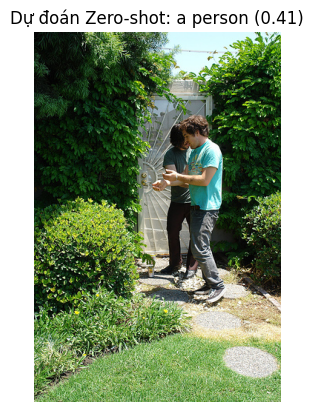

Lớp: a cat           - Xác suất: 0.0956
Lớp: a dog           - Xác suất: 0.1740
Lớp: a person        - Xác suất: 0.4140
Lớp: a car           - Xác suất: 0.0596
Lớp: a building      - Xác suất: 0.0389
Lớp: a landscape     - Xác suất: 0.2178


In [44]:
import torch
from transformers import CLIPProcessor, CLIPModel

# 1. Tải mô hình pre-trained CLIP
model_name = "openai/clip-vit-base-patch32"
model_clip = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# 2. Hàm phân loại Zero-shot
def zero_shot_classification(image, labels):
    # Preprocess ảnh và text đồng thời
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = model_clip(**inputs)

    # Lấy xác suất (logits_per_image) sau khi đi qua Softmax
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

    return probs.cpu().numpy()[0]

probs = zero_shot_classification(img, candidate_labels)
pred_label = candidate_labels[probs.argmax()]

# 4. Hiển thị kết quả
plt.imshow(img)
plt.title(f"Dự đoán Zero-shot: {pred_label} ({probs.max():.2f})")
plt.axis('off')
plt.show()

for label, prob in zip(candidate_labels, probs):
    print(f"Lớp: {label:15} - Xác suất: {prob:.4f}")

* Mô hình: openai/clip-vit-base-patch32.

* Cơ chế: Mô hình tính toán độ tương đồng (Cosine Similarity) giữa vector đặc trưng của ảnh và vector đặc trưng của 6 nhãn văn bản. Lớp có xác suất cao nhất (Softmax) sẽ được chọn làm kết quả dự đoán.

* Ưu điểm: Không cần huấn luyện lại, có khả năng nhận diện các khái niệm mới dựa trên kiến thức khổng lồ đã học từ Internet.

### Hướng tiếp cận Few-shot Classification

In [45]:
import os
import random
from PIL import Image

# Định nghĩa từ khóa đặc trưng cho 6 lớp của bạn
class_keywords = {
    0: "dog",
    1: "cat",
    2: "person",
    3: "car",
    4: "building",
    5: "mountain"
}

few_shot_images = []
few_shot_labels = []
test_images = []
test_labels = []

# Đọc file captions để lọc ảnh theo lớp
used_image_ids = set()

for label_idx, keyword in class_keywords.items():
    # Lọc các image_id mà trong caption có chứa từ khóa của lớp
    relevant_ids = df_captions[df_captions['comment'].str.contains(keyword, case=False, na=False)]['image_name'].unique()
    relevant_ids = [rid for rid in relevant_ids if rid not in used_image_ids]

    # Xáo trộn để lấy ngẫu nhiên
    random.shuffle(relevant_ids)

    # 1. Lấy 5 ảnh cho Few-shot Train
    train_ids = relevant_ids[:5]
    for img_id in train_ids:
        img_path = os.path.join('/content/kaggle_data/flickr_image/flickr30k_images/flickr30k_images', img_id)
        few_shot_images.append(Image.open(img_path).convert("RGB"))
        few_shot_labels.append(label_idx)
        used_image_ids.add(img_id)

    # 2. Lấy 20 ảnh tiếp theo cho tập Test (để so sánh Accuracy)
    test_ids = relevant_ids[5:25]
    for img_id in test_ids:
        img_path = os.path.join('/content/kaggle_data/flickr_image/flickr30k_images/flickr30k_images', img_id)
        test_images.append(Image.open(img_path).convert("RGB"))
        test_labels.append(label_idx)
        used_image_ids.add(img_id)

print(f"Đã load {len(few_shot_images)} ảnh cho Few-shot Train (5 ảnh/lớp)")
print(f"Đã load {len(test_images)} ảnh cho tập Test để so sánh")

Đã load 30 ảnh cho Few-shot Train (5 ảnh/lớp)
Đã load 120 ảnh cho tập Test để so sánh


In [46]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Hàm trích xuất đặc trưng ảnh (Image Embeddings)
def get_image_embeddings(image):
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        # model_clip.get_image_features() returns BaseModelOutputWithPooling object in some environments
        # Access the actual embedding tensor via .pooler_output
        raw_features = model_clip.get_image_features(**inputs)
        image_features = raw_features.pooler_output if hasattr(raw_features, 'pooler_output') else raw_features
    return image_features.cpu().numpy()[0]

# 3. Huấn luyện Few-shot classifier
X_few_shot = [get_image_embeddings(img) for img in few_shot_images]
y_few_shot = few_shot_labels

# Dùng Logistic Regression làm classifier (Yêu cầu 2.5)
clf_few_shot = LogisticRegression(random_state=42)
clf_few_shot.fit(X_few_shot, y_few_shot)

# 4. Đánh giá trên tập Test Few-shot (Yêu cầu 4.4 - So sánh hiệu năng)
# (Bạn cần lấy 1 tập ảnh test riêng để đánh giá)
X_test_few_shot = [get_image_embeddings(img) for img in test_images]
y_pred_few_shot = clf_few_shot.predict(X_test_few_shot)

accuracy_few_shot = accuracy_score(test_labels, y_pred_few_shot)
print(f"Accuracy Few-shot (5 samples/class): {accuracy_few_shot:.4f}")

Accuracy Few-shot (5 samples/class): 0.4833


* Cơ chế: Trích xuất đặc trưng ảnh (Image Embeddings) từ lớp pooler_output của CLIP.

* Huấn luyện: Sử dụng 30 mẫu ảnh ít ỏi để huấn luyện một bộ phân loại tuyến tính Logistic Regression.

* Mục đích: Kiểm tra khả năng thích nghi của mô hình với một lượng dữ liệu cực nhỏ (5 mẫu/lớp).

## Confusion Matrix

📊 Đang thu thập dự đoán từ 2 mô hình...


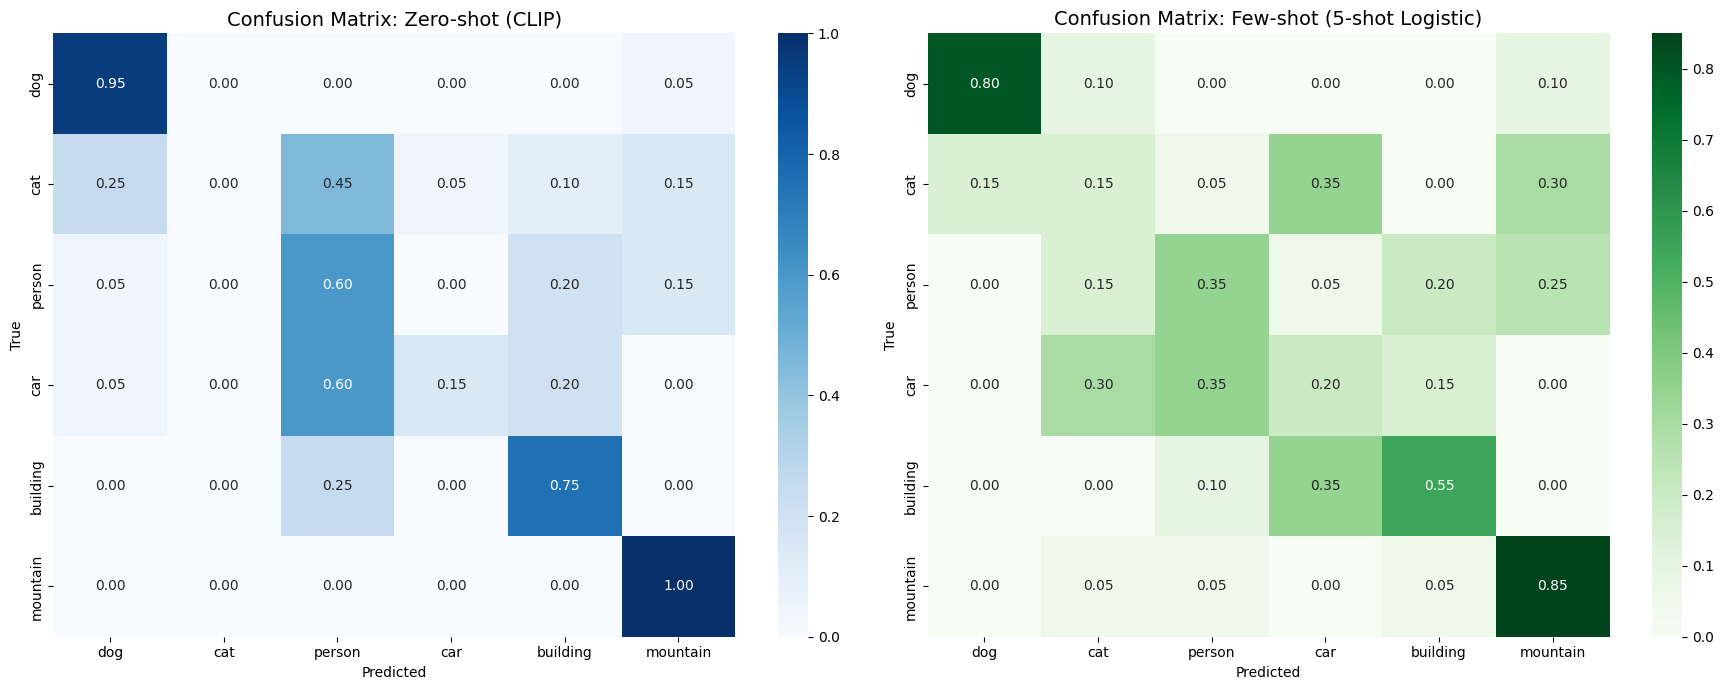

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_multimodal_confusion_matrices(y_true, zero_preds, few_preds, labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # 1. Ma trận cho Zero-shot
    cm_zero = confusion_matrix(y_true, zero_preds)
    cm_zero_perc = cm_zero.astype('float') / cm_zero.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_zero_perc, annot=True, fmt='.2f', cmap='Blues', ax=ax1,
                xticklabels=labels, yticklabels=labels)
    ax1.set_title('Confusion Matrix: Zero-shot (CLIP)', fontsize=14)
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')

    # 2. Ma trận cho Few-shot
    cm_few = confusion_matrix(y_true, few_preds)
    cm_few_perc = cm_few.astype('float') / cm_few.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_few_perc, annot=True, fmt='.2f', cmap='Greens', ax=ax2,
                xticklabels=labels, yticklabels=labels)
    ax2.set_title('Confusion Matrix: Few-shot (5-shot Logistic)', fontsize=14)
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')

    plt.tight_layout()
    plt.show()

# --- CHẠY DỰ ĐOÁN ĐỂ LẤY DỮ LIỆU VẼ ---
print("📊 Đang thu thập dự đoán từ 2 mô hình...")
all_zero_preds = []
all_few_preds = []

for img in test_images:
    # Lấy dự đoán Zero-shot
    zs_probs = zero_shot_classification(img, list(class_keywords.values()))
    all_zero_preds.append(np.argmax(zs_probs))

    # Lấy dự đoán Few-shot
    feat = get_image_embeddings(img)
    few_pred = clf_few_shot.predict([feat])[0]
    all_few_preds.append(few_pred)

# Gọi hàm vẽ
candidate_labels_text = list(class_keywords.values())
plot_multimodal_confusion_matrices(test_labels, all_zero_preds, all_few_preds, candidate_labels_text)

1. Phân tích Zero-shot:
* Điểm mạnh: CLIP Zero-shot làm cực tốt ở các lớp có đặc trưng thị giác rõ rệt: mountain (100%), dog (95%) và building (75%).

* Điểm yếu (Nhầm lẫn ngữ cảnh): Lớp car bị nhầm sang person (60%) và lớp cat cũng bị nhầm sang person (45%).

2. Phân tích Few-shot 5-shot:
* Hiện tượng: Độ chính xác ở các lớp như cat, person, car bị giảm mạnh so với Zero-shot (ví dụ cat chỉ còn 15%).